In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

import warnings
warnings.filterwarnings('ignore') # Вимикаємо зайві попередження

In [31]:
# Завантажуємо датасет
df = pd.read_csv("../data/test_3/Test_3.csv", sep=';')

# Перетворюємо дати у правильний формат datetime
df['time_stamp'] = pd.to_datetime(df['time_stamp'], format='%d.%m.%Y %H:%M')
df['reg_date'] = pd.to_datetime(df['reg_date'], format='%d.%m.%Y')

print(f"Загальний розмір датасету: {df.shape[0]} рядків")

Загальний розмір датасету: 768439 рядків


In [32]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 768439 entries, 0 to 768438
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   sender_id    768439 non-null  int64         
 1   platform_id  768439 non-null  int64         
 2   time_stamp   768439 non-null  datetime64[us]
 3   gender       768439 non-null  str           
 4   reg_date     768439 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(2), str(1)
memory usage: 60.1 MB


In [33]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'], format='%d.%m.%Y %H:%M')
df['reg_date'] = pd.to_datetime(df['reg_date'], format='%d.%m.%Y')

In [34]:
df.head(3)

,sender_id,platform_id,time_stamp,gender,reg_date
0,3207526951,6,2017-03-16 13:35:00,m,2017-01-26
1,3207526951,6,2017-03-16 09:09:00,m,2017-01-26
2,3207526951,6,2017-03-16 09:09:00,m,2017-01-26


In [35]:
# Точка відліку - старт тестування
split_date = '2017-03-24 16:00:00'

# Історичні дані для А/А тесту (до 24 березня 16:00)
df_before = df.query("time_stamp < @split_date").copy()

# Дані самого експерименту для А/В тесту (після 24 березня 16:00)
df_after = df.query("time_stamp >= @split_date").copy()

print(f"Розмір даних ДО тесту (A/A): {df_before.shape[0]} рядків")
print(f"Розмір даних ПІД ЧАС тесту (A/B): {df_after.shape[0]} рядків")

Розмір даних ДО тесту (A/A): 660847 рядків
Розмір даних ПІД ЧАС тесту (A/B): 107592 рядків


In [36]:
# Застосовуємо правило: непарні sender_id - test, парні - control
# Робимо це для обох датасетів

df_before['group'] = np.where(df_before['sender_id'] % 2 != 0, 'test', 'control')
df_after['group'] = np.where(df_after['sender_id'] % 2 != 0, 'test', 'control')

# Перевіримо, чи рівномірно розподілилися унікальні користувачі в періоді експерименту
print("Унікальних користувачів під час тесту:")
print(df_after.groupby('group')['sender_id'].nunique())

Унікальних користувачів під час тесту:
group
control    3726
test       3607
Name: sender_id, dtype: int64


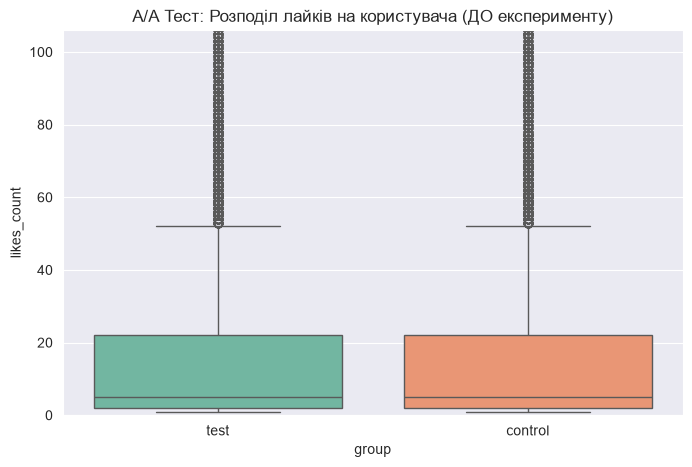

A/A Test P-value: 0.6690
Висновок: P-value > 0.05. Групи однорідні, сплітування пройшло успішно. Можна переходити до A/B тесту.


In [37]:
# Рахуємо кількість лайків на кожного користувача в історичних даних
likes_aa = df_before.groupby(['sender_id', 'group']).size().reset_index(name='likes_count')

# Відокремлюємо вибірки
test_aa = likes_aa[likes_aa['group'] == 'test']['likes_count']
control_aa = likes_aa[likes_aa['group'] == 'control']['likes_count']

# Візуалізація А/А тесту
plt.figure(figsize=(8, 5))
sns.boxplot(data=likes_aa, x='group', y='likes_count', palette='Set2')
plt.title('А/А Тест: Розподіл лайків на користувача (ДО експерименту)')
plt.ylim(0, likes_aa['likes_count'].quantile(0.95)) # Відрізаємо 5% екстремальних викидів для наочності графіка
plt.show()

# Статистична перевірка
stat_aa, p_value_aa = mannwhitneyu(test_aa, control_aa, alternative='two-sided')
print(f"A/A Test P-value: {p_value_aa:.4f}")

if p_value_aa > 0.05:
    print("Висновок: P-value > 0.05. Групи однорідні, сплітування пройшло успішно. Можна переходити до A/B тесту.")
else:
    print("Висновок: УВАГА! P-value < 0.05. Групи відрізнялися ще до тесту. Результатам A/B тесту довіряти не можна.")

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,3726.0,15.466452,44.782857,1.0,2.0,5.0,15.0,1154.0
test,3607.0,13.851955,26.280121,1.0,1.0,5.0,16.0,402.0


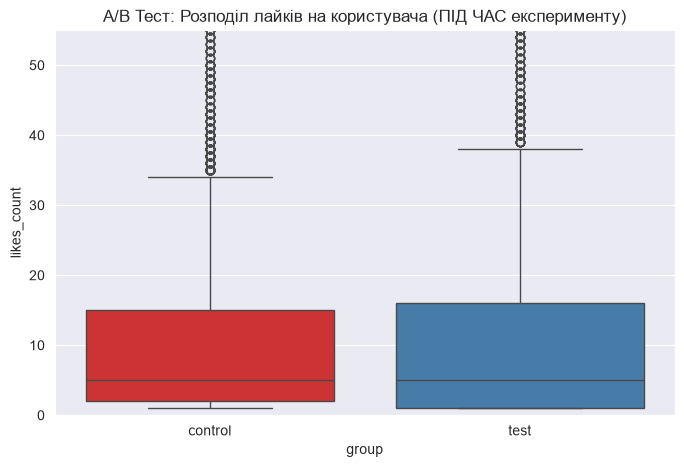

A/B Test P-value: 0.5045
Висновок: P-value > 0.05. Статистично значущої різниці між варіантами немає. Заміна серця на галочку не дала ефекту. Відхиляємо.


In [38]:
# Рахуємо кількість лайків на кожного користувача в період експерименту
likes_ab = df_after.groupby(['sender_id', 'group']).size().reset_index(name='likes_count')

# Виводимо описові статистики
display(likes_ab.groupby('group')['likes_count'].describe())

# Відокремлюємо вибірки
test_ab = likes_ab[likes_ab['group'] == 'test']['likes_count']
control_ab = likes_ab[likes_ab['group'] == 'control']['likes_count']

# Візуалізація А/В тесту
plt.figure(figsize=(8, 5))
sns.boxplot(data=likes_ab, x='group', y='likes_count', palette='Set1')
plt.title('А/В Тест: Розподіл лайків на користувача (ПІД ЧАС експерименту)')
plt.ylim(0, likes_ab['likes_count'].quantile(0.95)) # Відрізаємо викиди для наочності
plt.show()

# Статистична перевірка
stat_ab, p_value_ab = mannwhitneyu(test_ab, control_ab, alternative='two-sided')
print(f"A/B Test P-value: {p_value_ab:.4f}")

if p_value_ab < 0.05:
    if test_ab.mean() > control_ab.mean():
        print("Висновок: Нововведення (галочка) статистично значущо ЗБІЛЬШИЛО кількість лайків. Впроваджуємо для всіх.")
    else:
        print("Висновок: Нововведення (галочка) статистично значущо ЗМЕНШИЛО кількість лайків. Відхиляємо.")
else:
    print("Висновок: P-value > 0.05. Статистично значущої різниці між варіантами немає. Заміна серця на галочку не дала ефекту. Відхиляємо.")